# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

1. Please take some time to read through the paper and understand their approach, hypotheses and goals.

What was the objective of the study?

See if chronical neuropathical pain changes the brain's reaction to oxycodone exposure and the following withdrawal and which molecular mechanisms are responsible for that.

What do the conditions mean?

oxy: The mice are given oxycodone


sal: The mice are given saline

What do the genotypes mean?

SNI: Spared Nerve Injury, chronic pain and nerve damage


Sham: Control group, no chronic pain and no nerve damage

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.

What would you do?
Starting from the raw RNA-seq files, I would first perform quality control, followed by read alignment to the mouse reference genome and gene-level quantification. After additional sample-level quality control, I would normalize the count data and perform differential expression analysis, for example using DESeq2. Significant genes could subsequently be investigated using pathway/enrichment analysis.

Which groups would you compare to each other?
- Sham-Oxy vs. Sham-Sal: effect of oxycodone withdrawal without chronic pain. I would expect differential expression associated with oxycodone exposure/withdrawal.
- SNI-Sal vs. Sham-Sal: effect of chronic neuropathic pain alone. I would expect genes associated with long-term nerve injury and chronic pain to be differentially expressed.
- SNI-Oxy vs. SNI-Sal: effect of oxycodone withdrawal in the presence of chronic pain. I would expect additional or altered transcriptional responses to oxycodone withdrawal.
- SNI-Oxy vs. Sham-Oxy: effect of chronic pain on the response to oxycodone withdrawal. I would expect differences indicating that chronic pain modifies the molecular response to oxycodone.
- SNI-Oxy vs. Sham-Sal: combined effect of chronic pain and oxycodone withdrawal compared with the baseline control. I would expect substantial transcriptomic differences.
Additionally, I would test the interaction between injury and oxycodone treatment to identify genes for which the response to oxycodone depends on the presence of chronic neuropathic pain.

Please also mention which outcome you would expect to see from each comparison.

Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results
1. How many samples do you have per condition?
2. How many samples do you have per genotype?
3. How often do you have each condition per genotype?

In [ ]:
import pandas as pd
df = pd.read_excel('conditions_runs_oxy_project.xlsx')
df.head()

df["Condition"] = df["condition: Sal"].apply(
    lambda x: "Sal" if x == "x" else "Oxy"
)

df[["Run", "condition: Sal", "Condition: Oxy", "Condition"]].head()

df["Genotype"] = df["Genotype: SNI"].apply(
    lambda x: "SNI" if x == "x" else "Sham"
)

df[["Run", "Genotype: SNI", "Genotype: Sham", "Genotype"]].head()

condition_check = (
    df[["condition: Sal", "Condition: Oxy"]]
    .eq("x")
    .sum(axis=1)
)

genotype_check = (
    df[["Genotype: SNI", "Genotype: Sham"]]
    .eq("x")
    .sum(axis=1)
)

print("Condition markers per sample:")
print(condition_check.value_counts())

print("\nGenotype markers per sample:")
print(genotype_check.value_counts())

clean_df = df[["Run", "Condition", "Genotype"]].copy()
clean_df

Condition markers per sample:
1    16
Name: count, dtype: int64

Genotype markers per sample:
1    16
Name: count, dtype: int64


,Run,Condition,Genotype
0,SRR23195505,Sal,SNI
1,SRR23195506,Oxy,Sham
2,SRR23195507,Sal,Sham
3,SRR23195508,Oxy,SNI
4,SRR23195509,Oxy,SNI
5,SRR23195510,Sal,SNI
6,SRR23195511,Oxy,Sham
7,SRR23195512,Sal,Sham
8,SRR23195513,Sal,SNI
9,SRR23195514,Oxy,Sham


In [12]:
# 1. How many samples do we have per condition?
samples_per_condition = clean_df["Condition"].value_counts()

print("Samples per condition:")
print(samples_per_condition)

Samples per condition:
Condition
Sal    8
Oxy    8
Name: count, dtype: int64


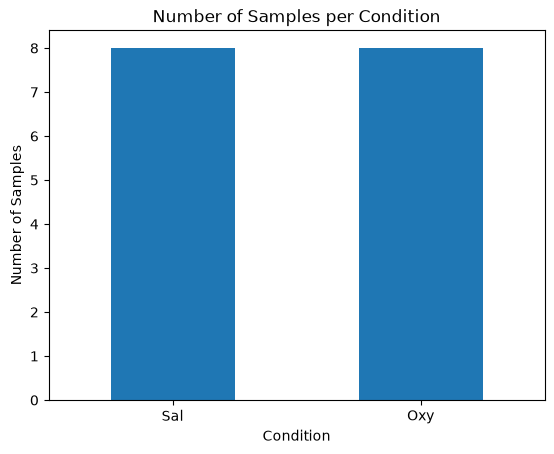

In [15]:
# Plot for question 1: Samples per condition
import matplotlib.pyplot as plt
samples_per_condition.plot(kind="bar")

plt.title("Number of Samples per Condition")
plt.xlabel("Condition")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

Samples per genotype:
Genotype
SNI     8
Sham    8
Name: count, dtype: int64


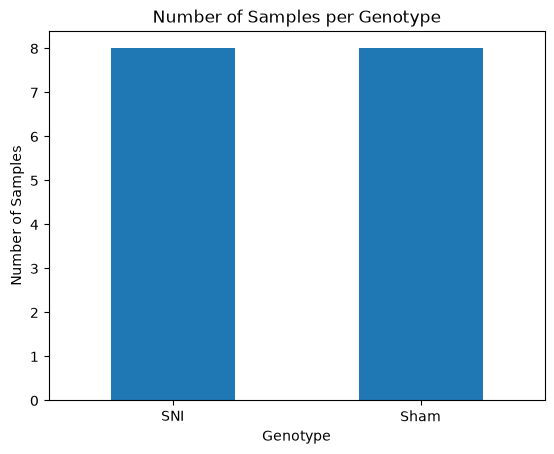

In [16]:
# 2. How many samples do we have per genotype?

samples_per_genotype = clean_df["Genotype"].value_counts()

print("Samples per genotype:")
print(samples_per_genotype)

# Plot samples per genotype
samples_per_genotype.plot(kind="bar")

plt.title("Number of Samples per Genotype")
plt.xlabel("Genotype")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

Conditions per genotype:
Condition  Oxy  Sal
Genotype           
SNI          4    4
Sham         4    4


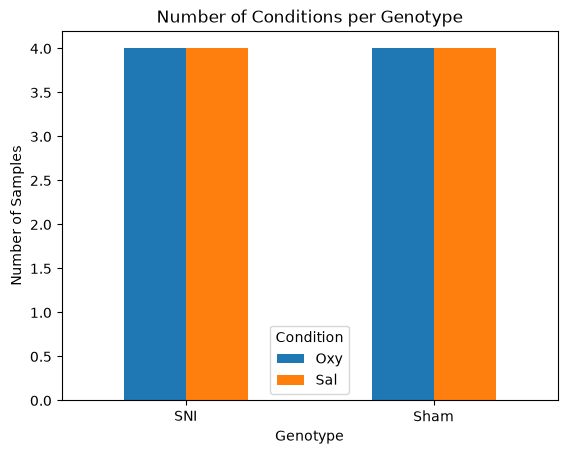

In [17]:
# 3. How often do we have each condition per genotype?

condition_per_genotype = pd.crosstab(
    clean_df["Genotype"],
    clean_df["Condition"]
)

print("Conditions per genotype:")
print(condition_per_genotype)

# Plot conditions per genotype
condition_per_genotype.plot(kind="bar")

plt.title("Number of Conditions per Genotype")
plt.xlabel("Genotype")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Condition")

plt.show()

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

Then select the 2 smallest runs from your dataset and download them from SRA (maybe an nf-core pipeline can help here?...)

In [18]:
# 511 and 516

# Load base count information

base_counts = pd.read_csv("base_counts.csv")

base_counts.head()

,Run,Bases
0,SRR23195505,6922564500
1,SRR23195506,7859530800
2,SRR23195507,8063298900
3,SRR23195508,6927786900
4,SRR23195509,7003550100


In [19]:
# Add base count information to the cleaned dataframe

clean_df = clean_df.merge(
    base_counts,
    on="Run",
    how="left"
)

# Sort by number of bases and condition
clean_df = clean_df.sort_values(
    by=["Bases", "Condition"]
).reset_index(drop=True)

clean_df

,Run,Condition,Genotype,Bases
0,SRR23195516,Oxy,SNI,6203117700
1,SRR23195511,Oxy,Sham,6456390900
2,SRR23195517,Oxy,SNI,6863840400
3,SRR23195505,Sal,SNI,6922564500
4,SRR23195508,Oxy,SNI,6927786900
5,SRR23195519,Oxy,Sham,6996050100
6,SRR23195509,Oxy,SNI,7003550100
7,SRR23195514,Oxy,Sham,7226808600
8,SRR23195510,Sal,SNI,7377388500
9,SRR23195512,Sal,Sham,7462857900


In [21]:
# Select the two smallest runs

smallest_runs = clean_df.nsmallest(2, "Bases")

smallest_runs[["Run"]].to_csv(
    "smallest_runs.csv",
    index=False,
    header=False
)

with open("smallest_runs.csv") as file:
    print(file.read())

smallest_runs

SRR23195516
SRR23195511



,Run,Condition,Genotype,Bases
0,SRR23195516,Oxy,SNI,6203117700
1,SRR23195511,Oxy,Sham,6456390900


In [26]:
!nextflow run nf-core/fetchngs \
    -r 1.13.0 \
    -profile docker \
    -c fetchngs.config \
    --input smallest_runs.csv \
    --outdir fetchngs_results \
    --download_method sratools \
    -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/fetchngs` [evil_leakey] revision: 955c892d80 [1.13.0]

WARN: Unrecognized config option 'manifest.diagram'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/fetchngs 1.13.0
------------------------------------------------------

Input/output options
  input              : smallest_runs.csv
  download_method    : sratools
  outdir             : fetchngs_results

Deprecated options
  trace_report_suffix: 2026-09-29_11-53-42

Core Nextflow options
  revision           : 1.13.0
  runName            : evil_leakey
  containerEngine    : docker
  launchDir          : /mnt/c/Users/alexa/documents/computationalworkflows2026/computational-workflows-2026/day_02
  

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>
When you are done with this shout, so we can discuss the different ideas.

### Reproducing the analysis

- Use the same raw data provided by the authors.
- Extract the exact analysis methods, parameters and thresholds reported in the paper.
- Try to use the same software and, where available, the same software versions.
- Recreate the experimental metadata and sample assignments from the available information.
- Reproduce the reported analysis as closely as possible.
- Recreate key results and figures from the paper.
- Compare obtained results (e.g. numbers of DEGs and expression patterns) with the published results.
- Document any information that is missing from the paper and assumptions that have to be made.
- Investigate possible reasons for differences between the reproduced and published results.
- Make the reproduction itself reproducible by documenting software, parameters and workflow.